   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

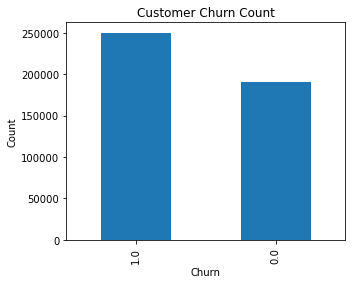

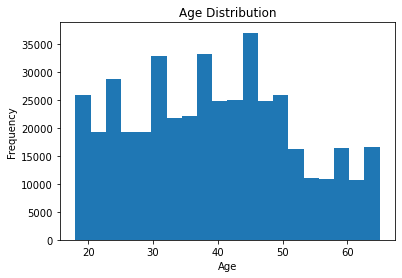

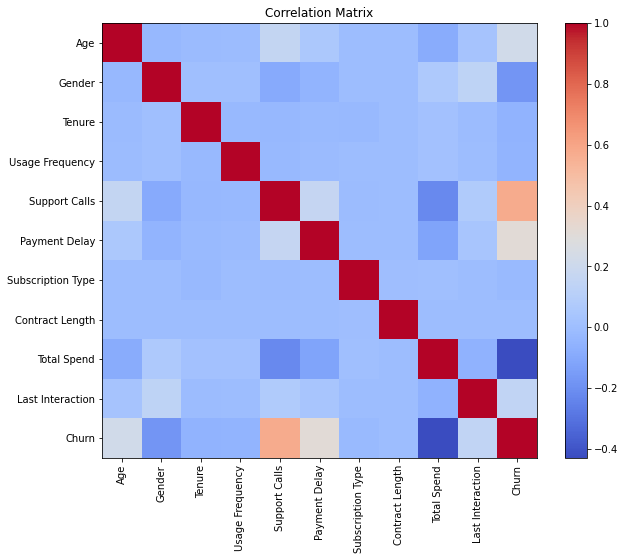

Scaled Features:
[[-7.53327082e-01 -1.14591125e+00  4.48759994e-01 -2.10510974e-01
   4.54550107e-01  6.09621432e-01  1.21154265e+00 -1.11466088e+00
   1.24742792e+00  2.93052343e-01]
 [ 2.05964832e+00 -1.14591125e+00  1.02827904e+00 -1.72456451e+00
   2.08310265e+00 -6.01319089e-01 -1.24555938e+00  1.69415975e-03
  -3.09865147e-01 -9.86584599e-01]
 [ 1.25594106e+00 -1.14591125e+00 -1.00003762e+00 -1.37516754e+00
   7.80260615e-01  6.09621432e-01 -1.24555938e+00  1.11804920e+00
  -1.85469987e+00 -1.33557649e+00]
 [ 1.49705324e+00  8.72667928e-01  3.90808089e-01  6.04748619e-01
   1.10597112e+00 -7.22413141e-01  1.21154265e+00  1.69415975e-03
  -9.78462971e-01  1.68901992e+00]
 [-1.31592216e+00  8.72667928e-01  4.30966620e-02  4.88282963e-01
   4.54550107e-01 -6.01319089e-01 -1.24555938e+00  1.69415975e-03
  -6.06982566e-02  6.42044236e-01]]
Training Samples: 352666
Testing Samples: 88167
Training Completed Successfully.
Predicted Values:
[0. 1. 0. ... 0. 1. 1.]

Accuracy = 0.8526886476

In [3]:
# CUSTOMER CHURN ANALYSIS USING LOGISTIC REGRESSION 

# 1.IMPORT THE LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2.LOAD THE DATASET

df=pd.read_csv(r"C:\Users\user\OneDrive\customer_churn_dataset-training-master.csv")
print(df.head())

# 3. UNDERSTAND THE DATA

print("Shape Of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())


# 4. DATA PREPROCESSING

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Drop CustomerID if present
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

print(df.head())


# 5. CATEGORICAL DATA

print("\n========== LABEL ENCODING ==========\n")

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

print(df.head())


# 6. EXPLORATORY DATA ANALYSIS

print("\n========== EDA ==========\n")

print(df["Churn"].value_counts())

# Churn Count
plt.figure(figsize=(5,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Age Distribution
if "Age" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["Age"], bins=20)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.show()

# Monthly Charges
if "MonthlyCharges" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["MonthlyCharges"], bins=20)
    plt.title("Monthly Charges Distribution")
    plt.xlabel("Monthly Charges")
    plt.ylabel("Frequency")
    plt.show()

# Correlation Matrix
plt.figure(figsize=(10,8))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")
plt.show()


# 7. SCALING

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
print(X_scaled[:5])


# 8. SPLIT THE DATA

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 9. CHOOSE THE MODEL

model = LogisticRegression(max_iter=1000)


# 10. TRAIN THE MODEL

model.fit(X_train, y_train)

print("Training Completed Successfully.")


# 11. TEST THE MODEL

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)


# 12. EVALUATE THE MODEL

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


# 13. PREDICT A NEW CUSTOMER

new_customer = [[
    35,      # Age
    1,       # Gender
    12,      # Tenure
    20,      # Usage Frequency
    2,       # Support Calls
    5,       # Payment Delay
    1,       # Subscription Type
    1,       # Contract Length
    5000,    # Total Spend
    15       # Last Interaction
]]

new_scaled = scaler.transform(new_customer)

prediction = model.predict(new_scaled)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Not Churn")

print("\n============ MACHINE LEARNING PIPELINE COMPLETED ============")# 

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

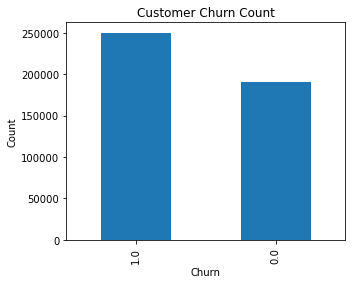

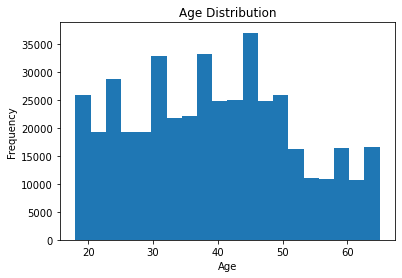

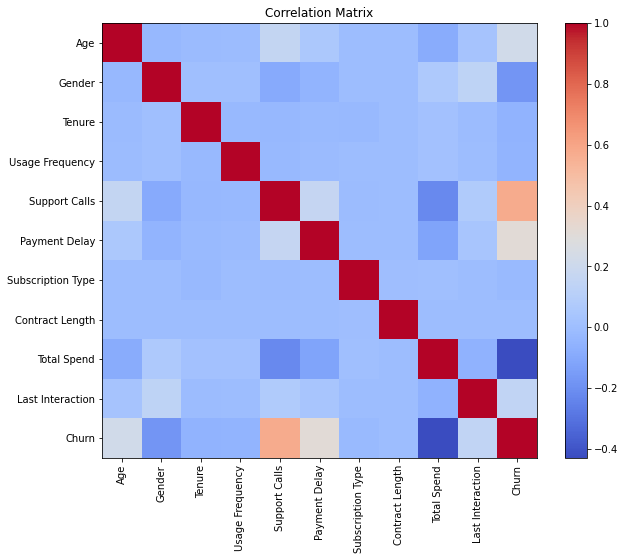

Scaled Features:
[[-7.53327082e-01 -1.14591125e+00  4.48759994e-01 -2.10510974e-01
   4.54550107e-01  6.09621432e-01  1.21154265e+00 -1.11466088e+00
   1.24742792e+00  2.93052343e-01]
 [ 2.05964832e+00 -1.14591125e+00  1.02827904e+00 -1.72456451e+00
   2.08310265e+00 -6.01319089e-01 -1.24555938e+00  1.69415975e-03
  -3.09865147e-01 -9.86584599e-01]
 [ 1.25594106e+00 -1.14591125e+00 -1.00003762e+00 -1.37516754e+00
   7.80260615e-01  6.09621432e-01 -1.24555938e+00  1.11804920e+00
  -1.85469987e+00 -1.33557649e+00]
 [ 1.49705324e+00  8.72667928e-01  3.90808089e-01  6.04748619e-01
   1.10597112e+00 -7.22413141e-01  1.21154265e+00  1.69415975e-03
  -9.78462971e-01  1.68901992e+00]
 [-1.31592216e+00  8.72667928e-01  4.30966620e-02  4.88282963e-01
   4.54550107e-01 -6.01319089e-01 -1.24555938e+00  1.69415975e-03
  -6.06982566e-02  6.42044236e-01]]
Training Samples: 352666
Testing Samples: 88167
Training Completed Successfully.
Predicted Values:
[0. 1. 1. ... 0. 1. 0.]

Accuracy = 0.9546542357

In [4]:
# CUSTOMER CHURN ANALYSIS USING DECISION TREE

# 1.IMPORT THE LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2.LOAD THE DATASET

df=pd.read_csv(r"C:\Users\user\OneDrive\customer_churn_dataset-training-master.csv")
print(df.head())

# 3. UNDERSTAND THE DATA

print("Shape Of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())


# 4. DATA PREPROCESSING

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Drop CustomerID if present
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

print(df.head())


# 5. CATEGORICAL DATA

print("\n========== LABEL ENCODING ==========\n")

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

print(df.head())


# 6. EXPLORATORY DATA ANALYSIS

print("\n========== EDA ==========\n")

print(df["Churn"].value_counts())

# Churn Count
plt.figure(figsize=(5,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Age Distribution
if "Age" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["Age"], bins=20)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.show()

# Monthly Charges
if "MonthlyCharges" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["MonthlyCharges"], bins=20)
    plt.title("Monthly Charges Distribution")
    plt.xlabel("Monthly Charges")
    plt.ylabel("Frequency")
    plt.show()

# Correlation Matrix
plt.figure(figsize=(10,8))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")
plt.show()


# 7. SCALING

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
print(X_scaled[:5])


# 8. SPLIT THE DATA

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 9. CHOOSE THE MODEL

model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    max_depth=5
)


# 10. TRAIN THE MODEL

model.fit(X_train, y_train)

print("Training Completed Successfully.")


# 11. TEST THE MODEL

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)


# 12. EVALUATE THE MODEL

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


# 13. PREDICT A NEW CUSTOMER

new_customer = [[
    35,      # Age
    1,       # Gender
    12,      # Tenure
    20,      # Usage Frequency
    2,       # Support Calls
    5,       # Payment Delay
    1,       # Subscription Type
    1,       # Contract Length
    5000,    # Total Spend
    15       # Last Interaction
]]

new_scaled = scaler.transform(new_customer)

prediction = model.predict(new_scaled)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Not Churn")

print("\n============ MACHINE LEARNING PIPELINE COMPLETED ============")


   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

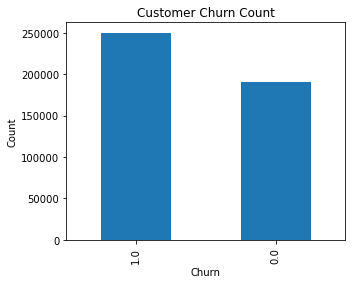

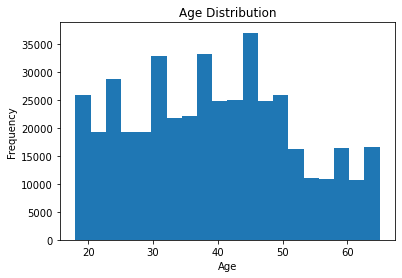

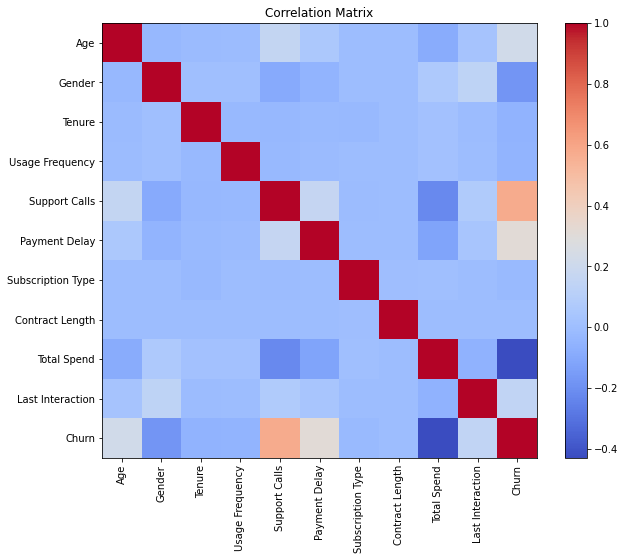

Scaled Features:
[[-7.53327082e-01 -1.14591125e+00  4.48759994e-01 -2.10510974e-01
   4.54550107e-01  6.09621432e-01  1.21154265e+00 -1.11466088e+00
   1.24742792e+00  2.93052343e-01]
 [ 2.05964832e+00 -1.14591125e+00  1.02827904e+00 -1.72456451e+00
   2.08310265e+00 -6.01319089e-01 -1.24555938e+00  1.69415975e-03
  -3.09865147e-01 -9.86584599e-01]
 [ 1.25594106e+00 -1.14591125e+00 -1.00003762e+00 -1.37516754e+00
   7.80260615e-01  6.09621432e-01 -1.24555938e+00  1.11804920e+00
  -1.85469987e+00 -1.33557649e+00]
 [ 1.49705324e+00  8.72667928e-01  3.90808089e-01  6.04748619e-01
   1.10597112e+00 -7.22413141e-01  1.21154265e+00  1.69415975e-03
  -9.78462971e-01  1.68901992e+00]
 [-1.31592216e+00  8.72667928e-01  4.30966620e-02  4.88282963e-01
   4.54550107e-01 -6.01319089e-01 -1.24555938e+00  1.69415975e-03
  -6.06982566e-02  6.42044236e-01]]
Training Samples: 352666
Testing Samples: 88167
Training Completed Successfully.
Predicted Values:
[1. 1. 1. ... 0. 1. 0.]

Accuracy = 0.9996370524

In [1]:
# CUSTOMER CHURN ANALYSIS USING RANDOM FOREST CLASSIFIER


# 1.IMPORT THE LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2.LOAD THE DATASET

df=pd.read_csv(r"C:\Users\user\OneDrive\customer_churn_dataset-training-master.csv")
print(df.head())

# 3. UNDERSTAND THE DATA

print("Shape Of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())


# 4. DATA PREPROCESSING

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Drop CustomerID if present
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

print(df.head())


# 5. CATEGORICAL DATA

print("\n========== LABEL ENCODING ==========\n")

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

print(df.head())


# 6. EXPLORATORY DATA ANALYSIS

print("\n========== EDA ==========\n")

print(df["Churn"].value_counts())

# Churn Count
plt.figure(figsize=(5,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Age Distribution
if "Age" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["Age"], bins=20)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.show()

# Monthly Charges
if "MonthlyCharges" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["MonthlyCharges"], bins=20)
    plt.title("Monthly Charges Distribution")
    plt.xlabel("Monthly Charges")
    plt.ylabel("Frequency")
    plt.show()

# Correlation Matrix
plt.figure(figsize=(10,8))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")
plt.show()


# 7. SCALING

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
print(X_scaled[:5])


# 8. SPLIT THE DATA

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 9. CHOOSE THE MODEL

model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=42
)


# 10. TRAIN THE MODEL

model.fit(X_train, y_train)

print("Training Completed Successfully.")


# 11. TEST THE MODEL

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)


# 12. EVALUATE THE MODEL

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


# 13. PREDICT A NEW CUSTOMER

new_customer = [[
    35,      # Age
    1,       # Gender
    12,      # Tenure
    20,      # Usage Frequency
    2,       # Support Calls
    5,       # Payment Delay
    1,       # Subscription Type
    1,       # Contract Length
    5000,    # Total Spend
    15       # Last Interaction
]]

new_scaled = scaler.transform(new_customer)

prediction = model.predict(new_scaled)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Not Churn")

print("\n============ MACHINE LEARNING PIPELINE COMPLETED ============")